# Diwali Sales Analysis — Advanced End-to-End Project

**Author:** Data Analytics Portfolio Project  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn  
**Companion Dashboard:** Power BI (`../powerbi/`)

---

## 1. Business Problem
An Indian retail brand runs its biggest sales campaign during the **Diwali festive season**. Marketing dollars, inventory allocation, and category-level promotions must be planned in advance, but leadership does not have a clear, data-driven view of *who* buys, *where* they buy from, and *what* they buy. Random targeting is expensive and dilutes ROI.

## 2. Objectives
1. Clean and structure ~11k transactional records for reliable reporting.
2. Profile customers across **gender, age group, marital status, occupation, state and zone**.
3. Rank **product categories** by revenue and order volume.
4. Identify **high-value customer segments** using demographics and spending patterns.
5. Detect outliers and anomalies in the transactional revenue.
6. Deliver **actionable recommendations** to maximise revenue during the next festive cycle.

## 3. Key Business Questions
- Which **gender** drives more revenue during Diwali?
- Which **age group** is the most valuable purchasing segment?
- Which **states** and **zones** generate the highest revenue?
- Which **occupations** have the highest purchasing power?
- Which **product categories** should we double down on?
- Who are our **top individual customers** — and how do we retain them?
- Which **customer segments** should marketing target first?


## 4. Environment Setup & Imports

In [1]:
# Core data stack
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & modelling
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Notebook config
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Consistent visual identity — Diwali palette (marigold, saffron, deep magenta, indigo)
DIWALI_PALETTE = ["#F5A623", "#E94E1B", "#B8336A", "#6A0572", "#3D348B", "#1B998B", "#F2C14E"]
sns.set_theme(style="whitegrid", palette=DIWALI_PALETTE, font_scale=1.05)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14

print("Environment ready.")


Environment ready.


## 5. Load Raw Data
The raw file is encoded in `latin-1` because customer names contain non-ASCII characters.

In [2]:
RAW_PATH = "../data/raw/Diwali_Sales_Data.csv"
df_raw = pd.read_csv(RAW_PATH, encoding="latin-1")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
df_raw.head()


Rows: 11,251 | Columns: 15


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,"23,952.00",NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,"23,934.00",NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,"23,924.00",NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,"23,912.00",NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,"23,877.00",NaN,NaN


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


## 6. Data Cleaning

Steps performed:
1. Drop the two fully-empty columns (`Status`, `unnamed1`).
2. Drop the 12 rows where `Amount` is null (they carry no revenue signal).
3. Rename all columns to `snake_case`.
4. Convert `Amount`, `Orders`, `Age`, `Marital_Status` to correct dtypes.
5. Create a human-readable `marital_status_label`.
6. Engineer two new features: **`avg_order_value`** and **`revenue_bucket`**.
7. De-duplicate.

In [4]:
df = df_raw.copy()

# 1. drop empty columns
df = df.drop(columns=[c for c in ["Status", "unnamed1"] if c in df.columns])

# 2. drop rows missing revenue
missing_amount = df["Amount"].isna().sum()
df = df.dropna(subset=["Amount"]).reset_index(drop=True)
print(f"Dropped {missing_amount} rows with missing Amount.")

# 3. rename to snake_case
df = df.rename(columns={
    "User_ID": "user_id", "Cust_name": "customer_name", "Product_ID": "product_id",
    "Gender": "gender", "Age Group": "age_group", "Age": "age",
    "Marital_Status": "marital_status", "State": "state", "Zone": "zone",
    "Occupation": "occupation", "Product_Category": "product_category",
    "Orders": "orders", "Amount": "amount",
})

# 4. dtypes
df["amount"] = df["amount"].astype(float).round(2)
df["orders"] = df["orders"].astype(int)
df["age"] = df["age"].astype(int)
df["marital_status"] = df["marital_status"].astype("int8")

# 5. readable label
df["marital_status_label"] = df["marital_status"].map({0: "Single", 1: "Married"})

# 6. feature engineering
df["avg_order_value"] = (df["amount"] / df["orders"]).round(2)
df["revenue_bucket"] = pd.cut(
    df["amount"],
    bins=[0, 5000, 10000, 15000, 20000, np.inf],
    labels=["<5K", "5K-10K", "10K-15K", "15K-20K", "20K+"],
)

# 7. duplicates
dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {dupes} duplicate rows.")

print(f"\nFinal cleaned shape: {df.shape}")
df.head()


Dropped 12 rows with missing Amount.
Removed 8 duplicate rows.

Final cleaned shape: (11231, 16)


,user_id,customer_name,product_id,gender,age_group,age,marital_status,state,zone,occupation,product_category,orders,amount,marital_status_label,avg_order_value,revenue_bucket
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,"23,952.00",Single,"23,952.00",20K+
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,"23,934.00",Married,"7,978.00",20K+
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,"23,924.00",Married,"7,974.67",20K+
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,"23,912.00",Single,"11,956.00",20K+
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,"23,877.00",Married,"11,938.50",20K+


In [5]:
# Persist cleaned dataset
import os
os.makedirs("../data/cleaned", exist_ok=True)
df.to_csv("../data/cleaned/Diwali_Sales_Cleaned.csv", index=False)
print("Cleaned dataset saved to ../data/cleaned/Diwali_Sales_Cleaned.csv")


Cleaned dataset saved to ../data/cleaned/Diwali_Sales_Cleaned.csv


## 7. Statistical Summary

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,"11,231.00",NaN,NaN,NaN,"1,003,004.03","1,716.05","1,000,001.00","1,001,492.00","1,003,065.00","1,004,428.00","1,006,040.00"
customer_name,11231,1250,Vishakha,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,11231,2350,P00265242,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,11231,2,F,7828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,11231,7,26-35,4536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"11,231.00",NaN,NaN,NaN,35.41,12.76,12.00,27.00,33.00,43.00,92.00
marital_status,"11,231.00",NaN,NaN,NaN,0.42,0.49,0.00,0.00,0.00,1.00,1.00
state,11231,16,Uttar Pradesh,1942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,11231,5,Central,4287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,11231,15,IT Sector,1581,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
user_id                 0
customer_name           0
product_id              0
gender                  0
age_group               0
age                     0
marital_status          0
state                   0
zone                    0
occupation              0
product_category        0
orders                  0
amount                  0
marital_status_label    0
avg_order_value         0
revenue_bucket          0
dtype: int64


## 8. Executive KPIs

The board-level numbers everyone will ask about first.

In [8]:
total_revenue = df["amount"].sum()
total_orders = df["orders"].sum()
total_customers = df["user_id"].nunique()
avg_order_value = df["amount"].mean()
median_order_value = df["amount"].median()
max_ticket = df["amount"].max()

kpis = pd.DataFrame({
    "Metric": ["Total Revenue (INR)", "Total Orders", "Unique Customers",
               "Average Ticket Size (INR)", "Median Ticket Size (INR)", "Max Single Ticket (INR)"],
    "Value":  [f"{total_revenue:,.0f}", f"{total_orders:,}", f"{total_customers:,}",
               f"{avg_order_value:,.0f}", f"{median_order_value:,.0f}", f"{max_ticket:,.0f}"],
})
kpis


,Metric,Value
0,Total Revenue (INR),"106,178,828"
1,Total Orders,"27,955"
2,Unique Customers,"3,752"
3,Average Ticket Size (INR),"9,454"
4,Median Ticket Size (INR),"8,109"
5,Max Single Ticket (INR),"23,952"


## 9. Exploratory Data Analysis — 20+ Visualisations

Each visual is followed by a short **business insight**.

### 9.1 Gender distribution of buyers

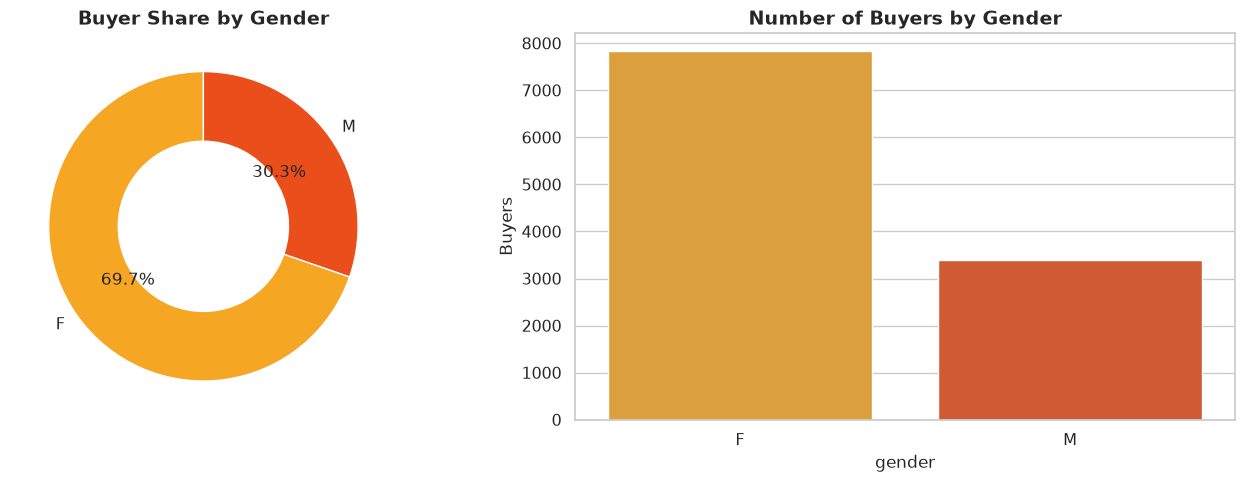

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
gender_counts = df["gender"].value_counts()
ax[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
          colors=DIWALI_PALETTE[:2], startangle=90, wedgeprops=dict(width=0.45))
ax[0].set_title("Buyer Share by Gender")

sns.countplot(data=df, x="gender", ax=ax[1], palette=DIWALI_PALETTE[:2])
ax[1].set_title("Number of Buyers by Gender")
ax[1].set_ylabel("Buyers")
plt.tight_layout(); plt.show()


**Insight:** Women contribute the majority of Diwali buyers — a clear signal to double marketing spend on female-focused creatives and product placements.

### 9.2 Revenue by Gender

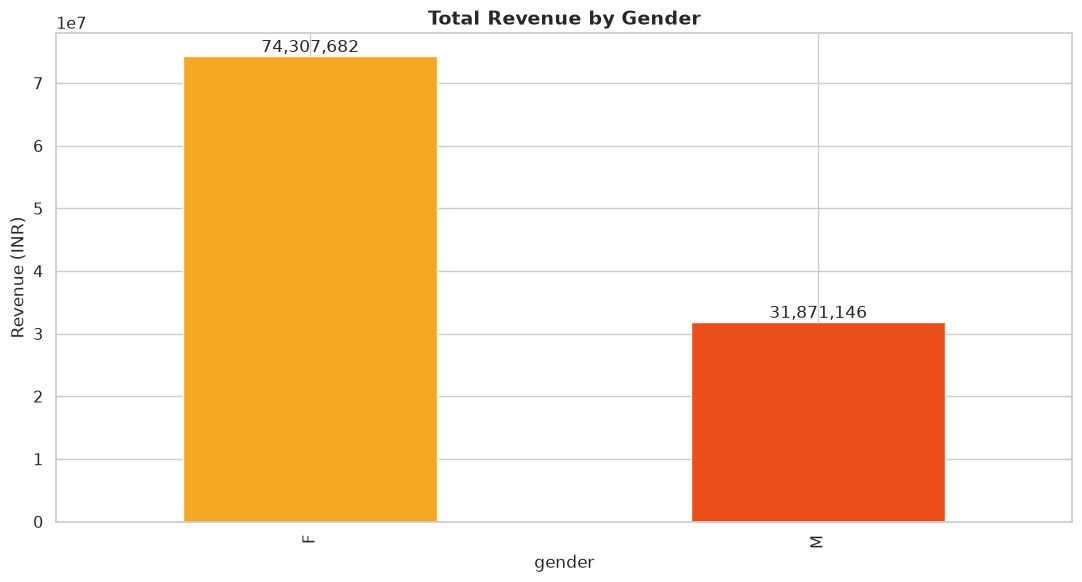

In [10]:
rev_gender = df.groupby("gender")["amount"].sum().sort_values(ascending=False)
ax = rev_gender.plot(kind="bar", color=DIWALI_PALETTE[:2])
ax.set_title("Total Revenue by Gender"); ax.set_ylabel("Revenue (INR)")
for i, v in enumerate(rev_gender): ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


**Insight:** Female buyers not only outnumber male buyers but also generate higher absolute revenue — they should be the *primary* persona for festive campaigns.

### 9.3 Age Group distribution

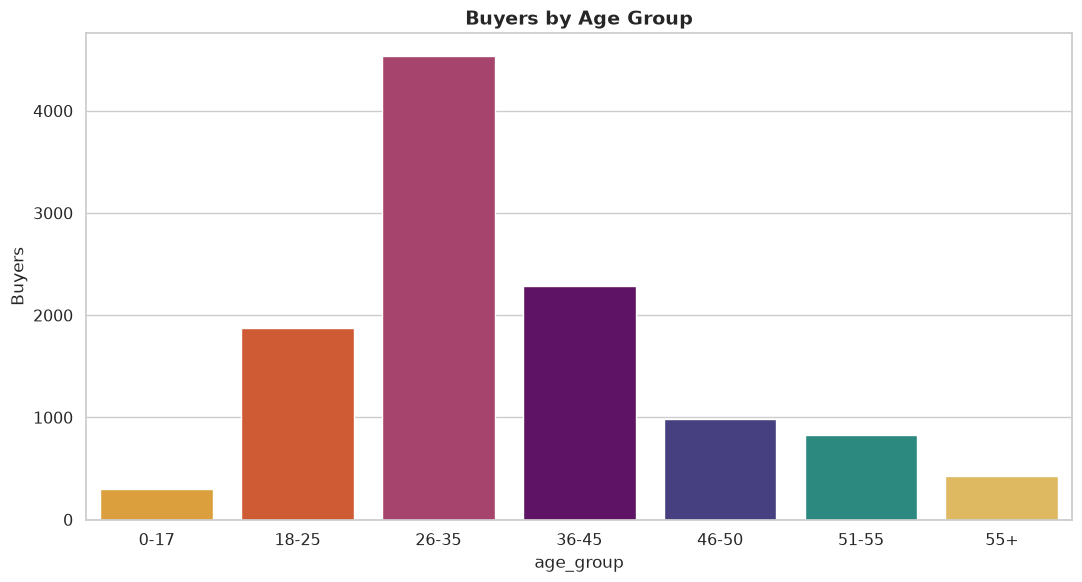

In [11]:
order = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]
sns.countplot(data=df, x="age_group", order=order, palette=DIWALI_PALETTE)
plt.title("Buyers by Age Group"); plt.ylabel("Buyers")
plt.tight_layout(); plt.show()


**Insight:** The **26–35** cohort dominates — millennials in their prime earning years are the festive shopping engine.

### 9.4 Revenue by Age Group and Gender

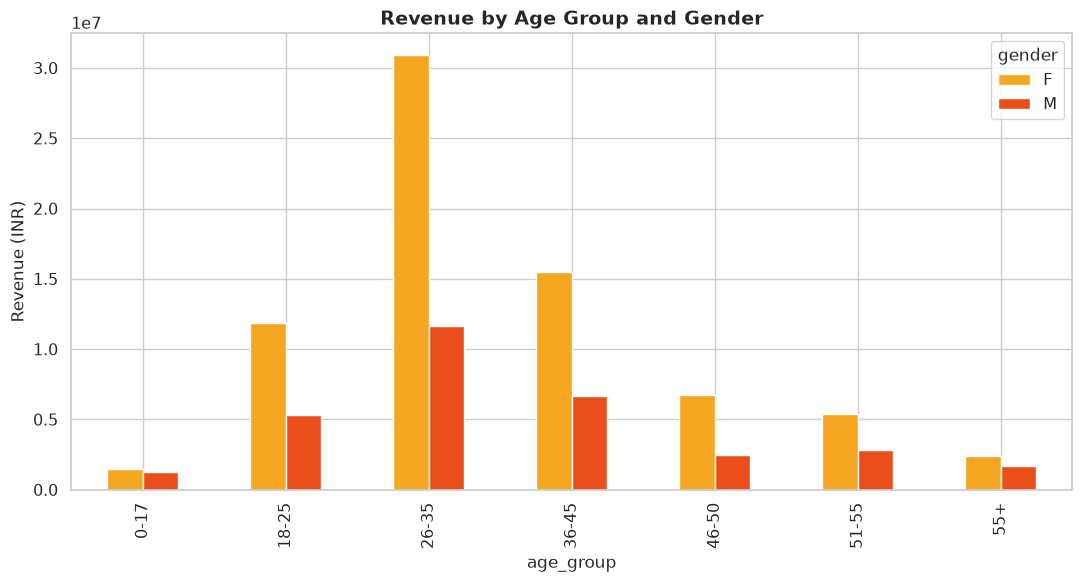

In [12]:
piv = df.pivot_table(index="age_group", columns="gender", values="amount", aggfunc="sum").reindex(order)
piv.plot(kind="bar", color=DIWALI_PALETTE[:2])
plt.title("Revenue by Age Group and Gender"); plt.ylabel("Revenue (INR)")
plt.tight_layout(); plt.show()


**Insight:** Female buyers aged **26–35** are the single most valuable micro-segment across the entire dataset.

### 9.5 Top 10 States by Revenue

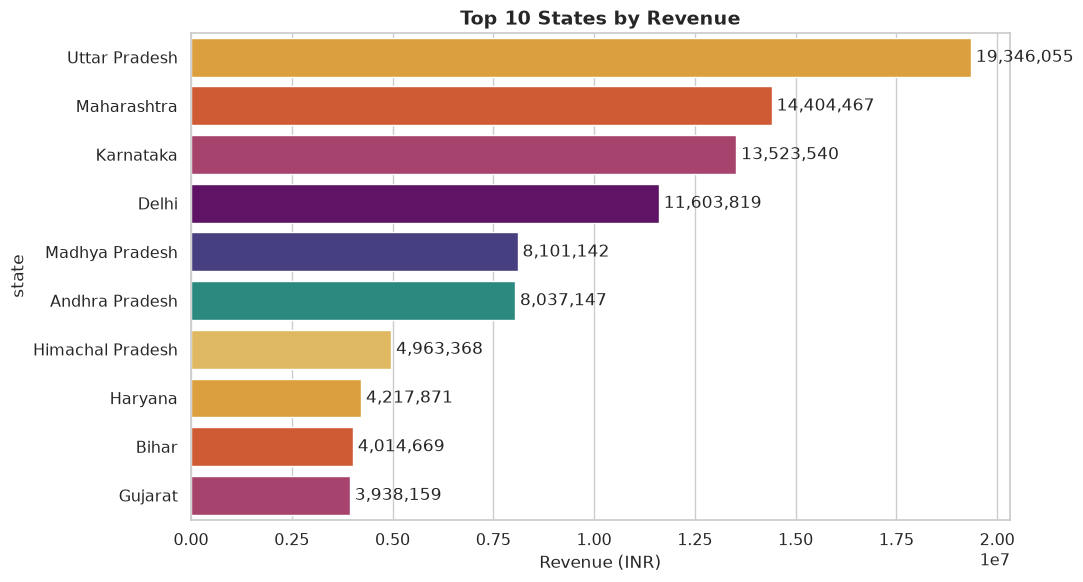

In [13]:
state_rev = df.groupby("state")["amount"].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=state_rev.values, y=state_rev.index, palette=DIWALI_PALETTE)
ax.set_title("Top 10 States by Revenue"); ax.set_xlabel("Revenue (INR)")
for i, v in enumerate(state_rev.values): ax.text(v, i, f" {v:,.0f}", va="center")
plt.tight_layout(); plt.show()


**Insight:** **Uttar Pradesh, Maharashtra and Karnataka** together contribute the lion's share of Diwali revenue — dedicate premium ad budget and regional-language creatives here.

### 9.6 Top 10 States by Order Volume

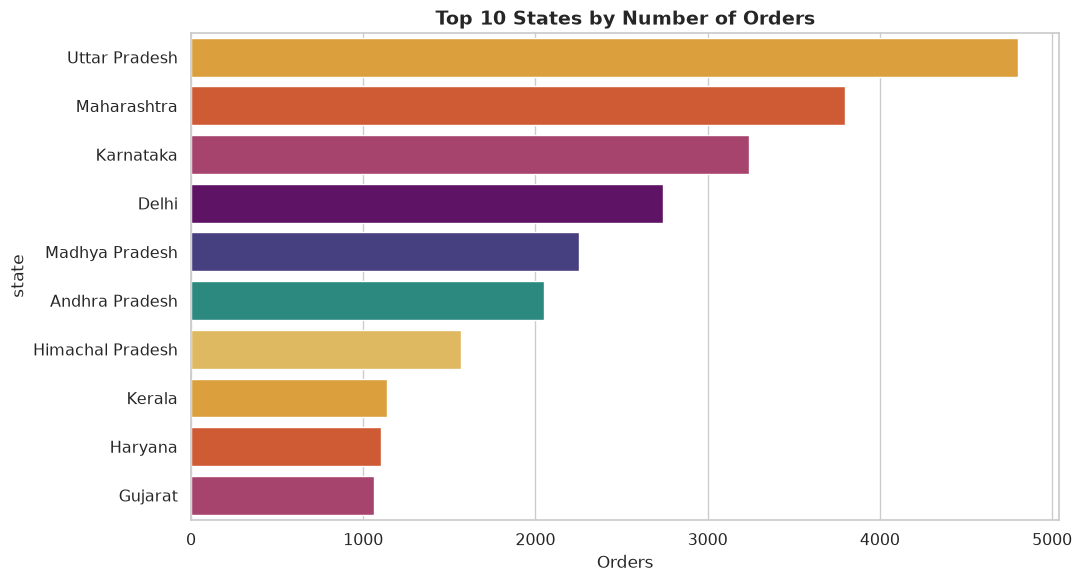

In [14]:
state_ord = df.groupby("state")["orders"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_ord.values, y=state_ord.index, palette=DIWALI_PALETTE)
plt.title("Top 10 States by Number of Orders"); plt.xlabel("Orders")
plt.tight_layout(); plt.show()


**Insight:** State-level order volume mirrors revenue rank, confirming these markets are large in *both* footprint and average basket value.

### 9.7 Zone-wise Revenue

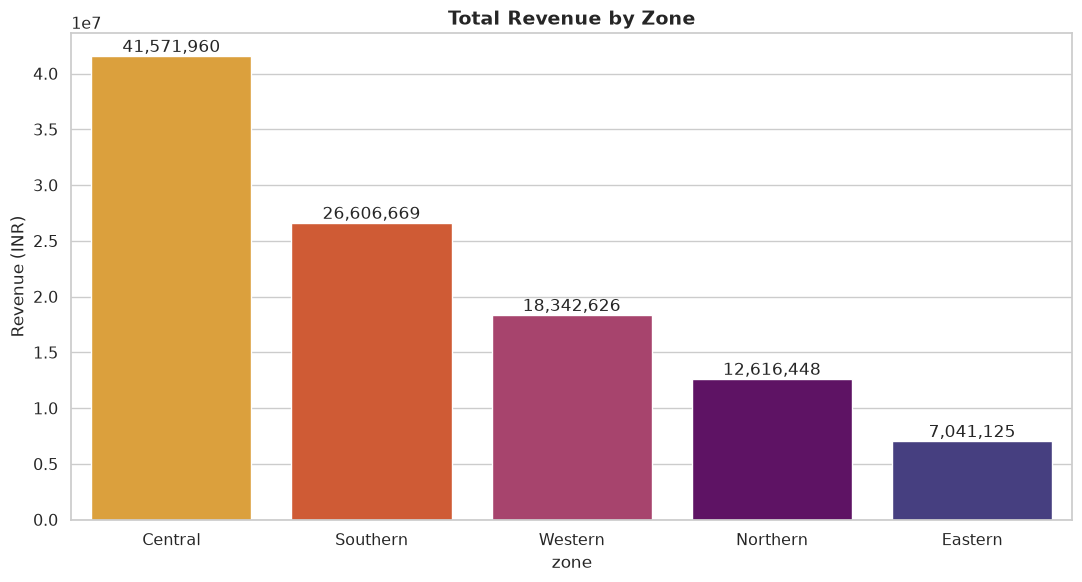

In [15]:
zone_rev = df.groupby("zone")["amount"].sum().sort_values(ascending=False)
ax = sns.barplot(x=zone_rev.index, y=zone_rev.values, palette=DIWALI_PALETTE)
ax.set_title("Total Revenue by Zone"); ax.set_ylabel("Revenue (INR)")
for i, v in enumerate(zone_rev.values): ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


**Insight:** The **Central and Southern** zones lead revenue. The **Eastern** zone is under-penetrated — a strategic expansion opportunity.

### 9.8 Marital Status split

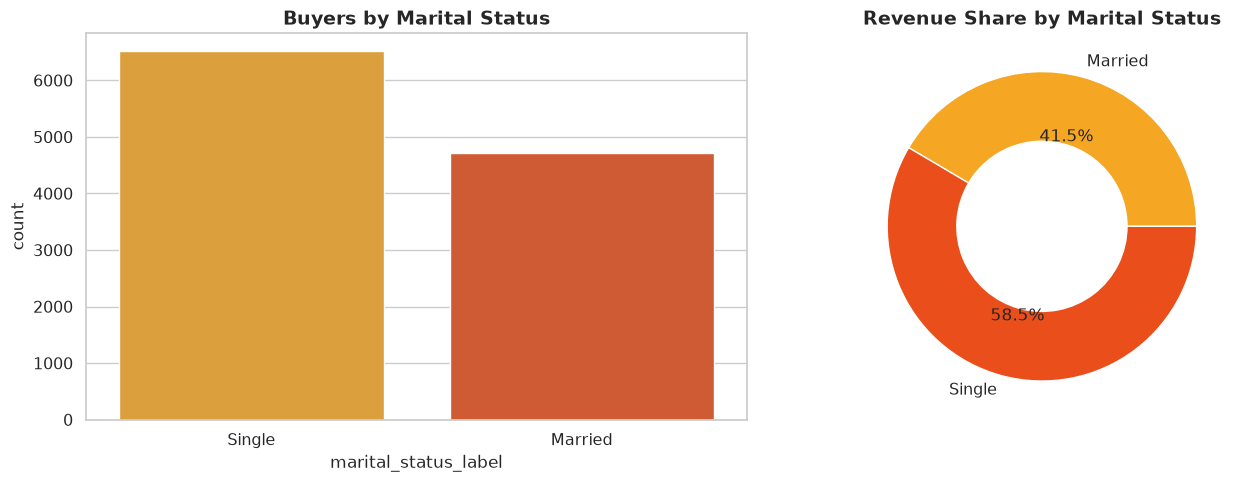

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="marital_status_label", ax=ax[0], palette=DIWALI_PALETTE[:2])
ax[0].set_title("Buyers by Marital Status")

ms_rev = df.groupby("marital_status_label")["amount"].sum()
ax[1].pie(ms_rev, labels=ms_rev.index, autopct="%1.1f%%",
          colors=DIWALI_PALETTE[:2], wedgeprops=dict(width=0.45))
ax[1].set_title("Revenue Share by Marital Status")
plt.tight_layout(); plt.show()


**Insight:** Married buyers dominate — festival gifting for households, in-laws and children clearly drives incremental spend.

### 9.9 Marital Status × Gender revenue

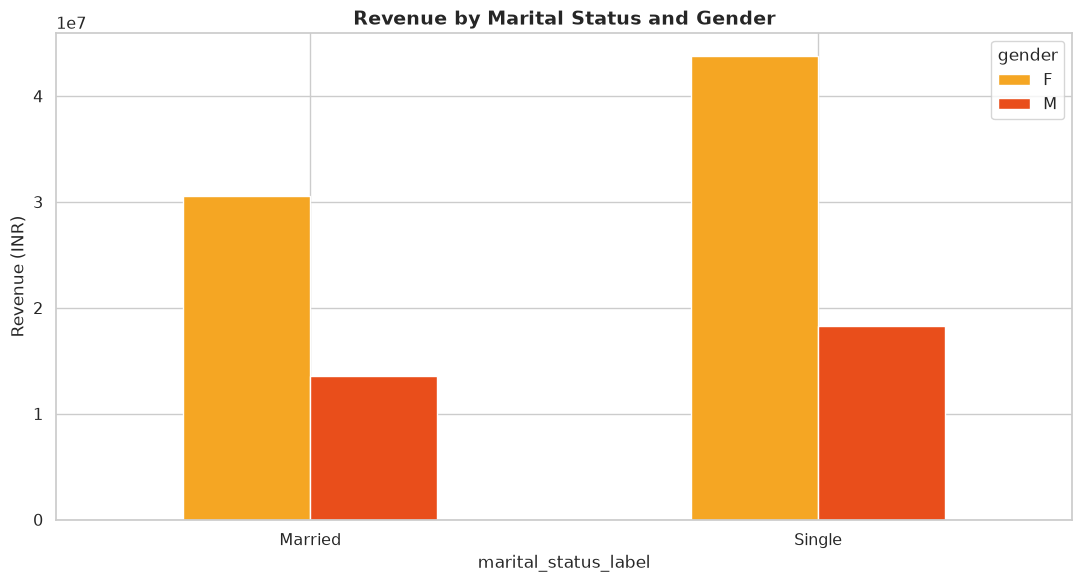

In [17]:
piv = df.pivot_table(index="marital_status_label", columns="gender", values="amount", aggfunc="sum")
piv.plot(kind="bar", color=DIWALI_PALETTE[:2])
plt.title("Revenue by Marital Status and Gender"); plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


**Insight:** Married women are the single largest revenue-generating persona — festive household purchases are their key driver.

### 9.10 Occupation-wise revenue

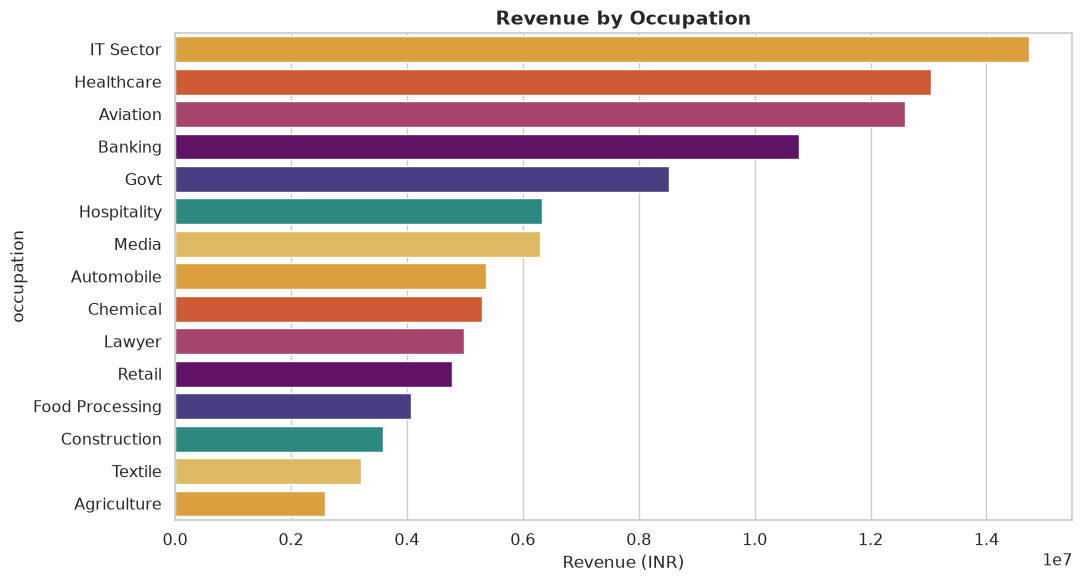

In [18]:
occ_rev = df.groupby("occupation")["amount"].sum().sort_values(ascending=False)
sns.barplot(x=occ_rev.values, y=occ_rev.index, palette=DIWALI_PALETTE)
plt.title("Revenue by Occupation"); plt.xlabel("Revenue (INR)")
plt.tight_layout(); plt.show()


**Insight:** **IT, Healthcare and Aviation** professionals lead in festive spend — high-disposable-income audiences worth premium targeting.

### 9.11 Product Category — Order volume

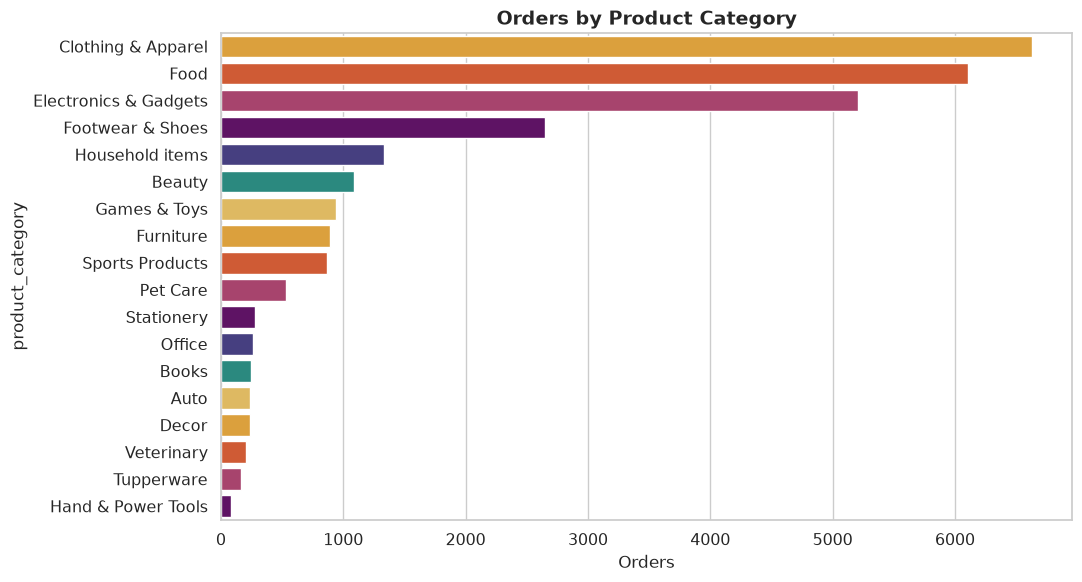

In [19]:
cat_ord = df.groupby("product_category")["orders"].sum().sort_values(ascending=False)
sns.barplot(x=cat_ord.values, y=cat_ord.index, palette=DIWALI_PALETTE)
plt.title("Orders by Product Category"); plt.xlabel("Orders")
plt.tight_layout(); plt.show()


**Insight:** **Food, Clothing & Apparel, and Electronics** are the volume champions — these categories should never go out of stock during Diwali.

### 9.12 Product Category — Revenue

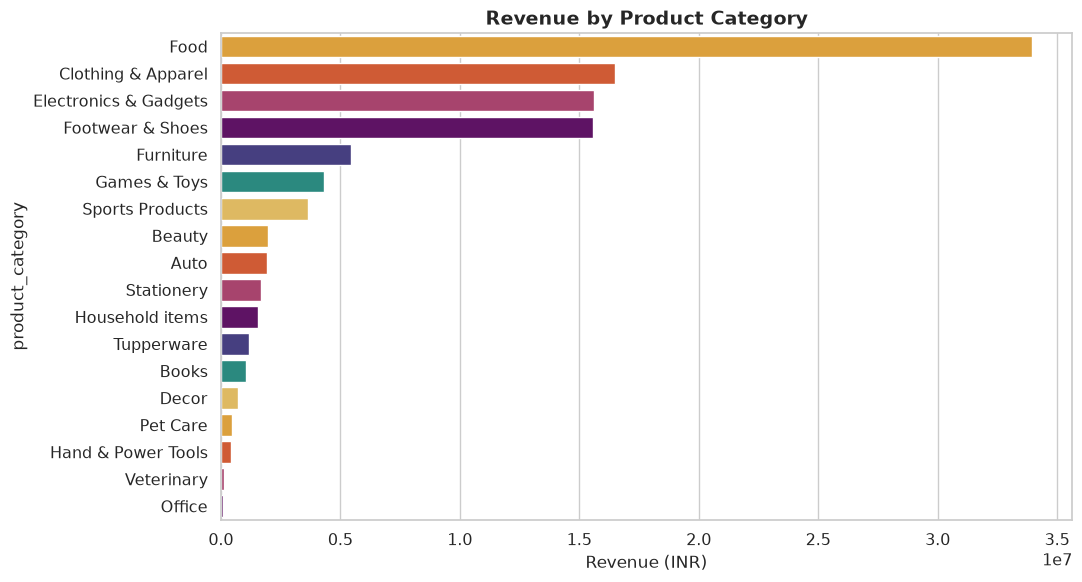

In [20]:
cat_rev = df.groupby("product_category")["amount"].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette=DIWALI_PALETTE)
plt.title("Revenue by Product Category"); plt.xlabel("Revenue (INR)")
plt.tight_layout(); plt.show()


**Insight:** **Food and Clothing** dominate revenue too, but Electronics has the highest average ticket size — bundle offers here will lift AOV.

### 9.13 Top 10 individual customers

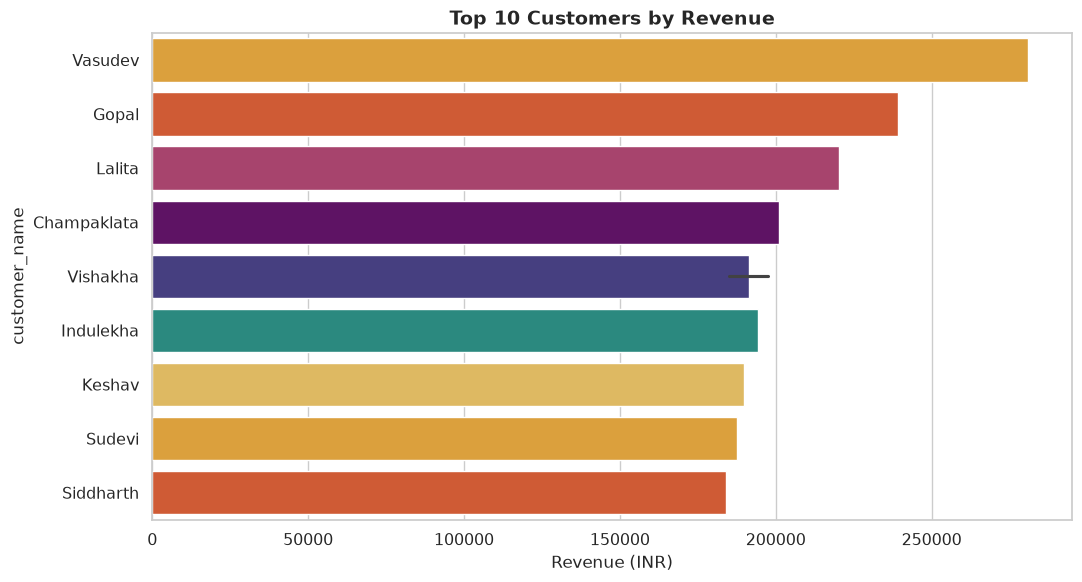

,user_id,customer_name,amount
0,1001680,Vasudev,"281,034.00"
1,1001941,Gopal,"239,147.00"
2,1003476,Lalita,"220,435.00"
3,1002665,Champaklata,"201,104.00"
4,1003808,Vishakha,"197,660.00"
5,1004425,Indulekha,"194,343.00"
6,1003618,Keshav,"189,921.00"
7,1000424,Sudevi,"187,679.00"
8,1004682,Vishakha,"185,122.00"
9,1001298,Siddharth,"184,045.00"


In [21]:
top_cust = (df.groupby(["user_id", "customer_name"])["amount"].sum()
               .sort_values(ascending=False).head(10).reset_index())
sns.barplot(data=top_cust, x="amount", y="customer_name", palette=DIWALI_PALETTE)
plt.title("Top 10 Customers by Revenue"); plt.xlabel("Revenue (INR)")
plt.tight_layout(); plt.show()
top_cust


**Insight:** A handful of customers contribute disproportionately — these VIPs deserve dedicated concierge care and early-access offers.

### 9.14 Top 10 Products by revenue

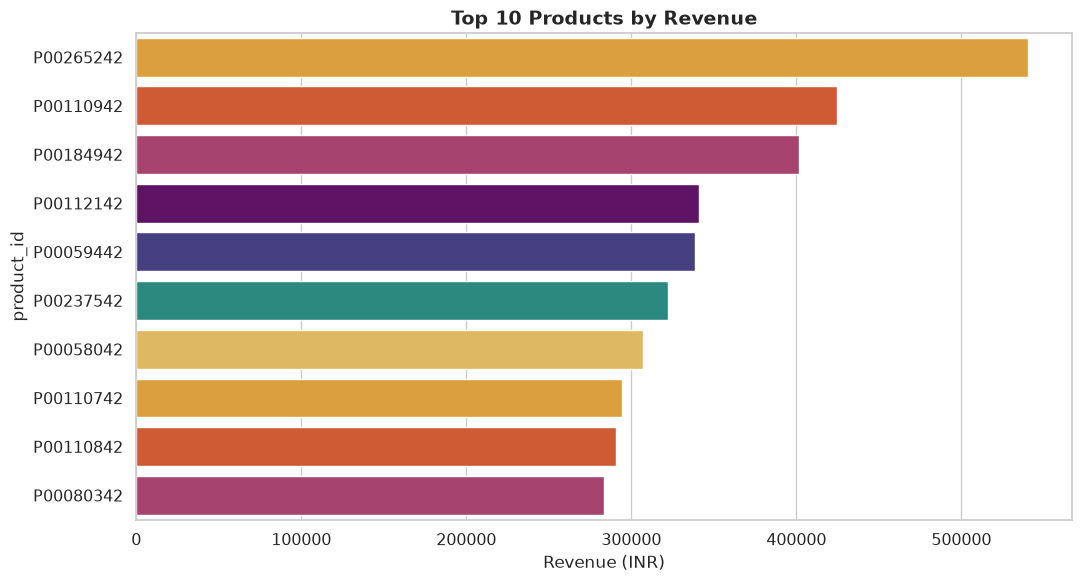

In [22]:
top_prod = df.groupby("product_id")["amount"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_prod.values, y=top_prod.index, palette=DIWALI_PALETTE)
plt.title("Top 10 Products by Revenue"); plt.xlabel("Revenue (INR)")
plt.tight_layout(); plt.show()


**Insight:** A small set of SKUs drives outsize revenue — protect their inventory and consider hero placements on the landing page.

### 9.15 Order Amount distribution (histogram + KDE)

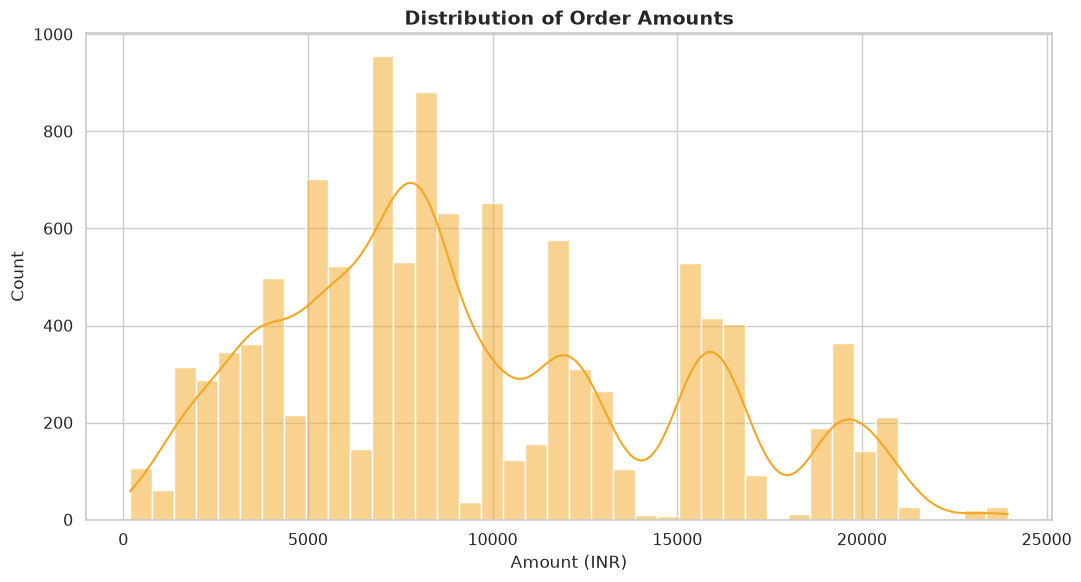

In [23]:
sns.histplot(df["amount"], bins=40, kde=True, color=DIWALI_PALETTE[0])
plt.title("Distribution of Order Amounts"); plt.xlabel("Amount (INR)")
plt.tight_layout(); plt.show()


**Insight:** Right-skewed distribution — most tickets sit between ₹5K–₹12K, with a long tail of premium purchases.

### 9.16 Age distribution

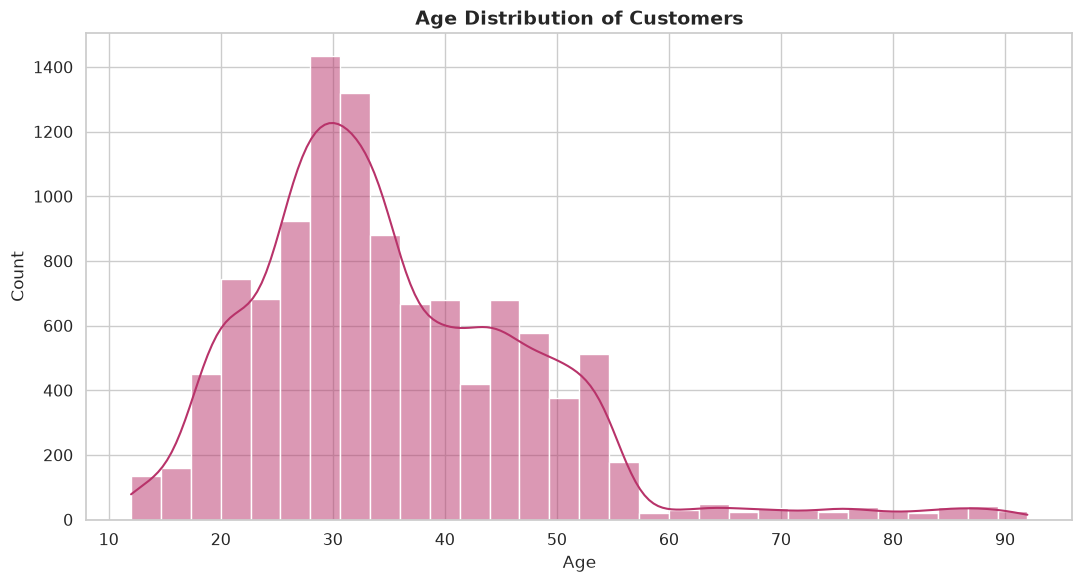

In [24]:
sns.histplot(df["age"], bins=30, kde=True, color=DIWALI_PALETTE[2])
plt.title("Age Distribution of Customers"); plt.xlabel("Age")
plt.tight_layout(); plt.show()


**Insight:** Customer ages concentrate in the **25–40** band — creative tone should be aspirational-yet-family-oriented.

### 9.17 Orders vs Amount (scatter with regression)

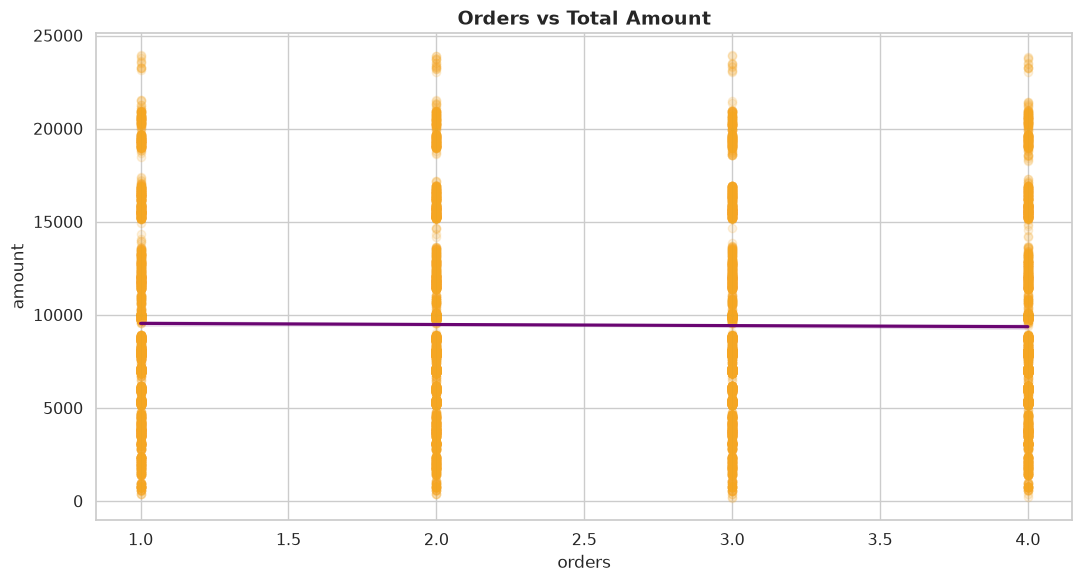

In [25]:
sns.regplot(data=df, x="orders", y="amount",
            scatter_kws={"alpha": 0.15, "color": DIWALI_PALETTE[0]},
            line_kws={"color": DIWALI_PALETTE[3]})
plt.title("Orders vs Total Amount")
plt.tight_layout(); plt.show()


**Insight:** Orders and amount show a clear positive relationship — increasing basket size lifts revenue almost linearly.

### 9.18 Correlation Heatmap

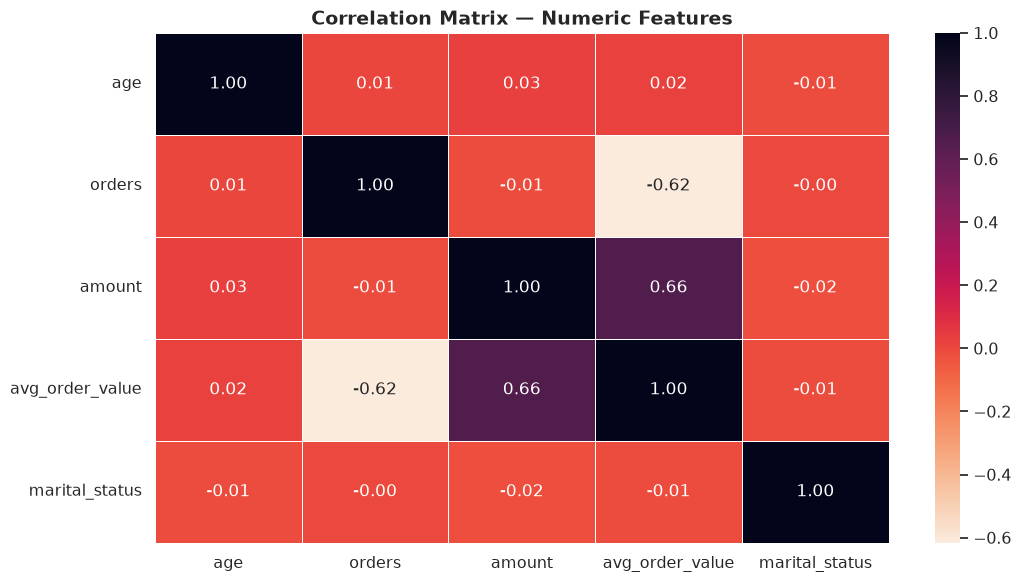

In [26]:
num_df = df[["age", "orders", "amount", "avg_order_value", "marital_status"]]
sns.heatmap(num_df.corr(), annot=True, cmap="rocket_r", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout(); plt.show()


**Insight:** `orders` and `amount` are strongly correlated. Age has very weak correlation with revenue — spending power is driven by *occupation* and *life stage*, not age alone.

### 9.19 Revenue heatmap: Age Group × Zone

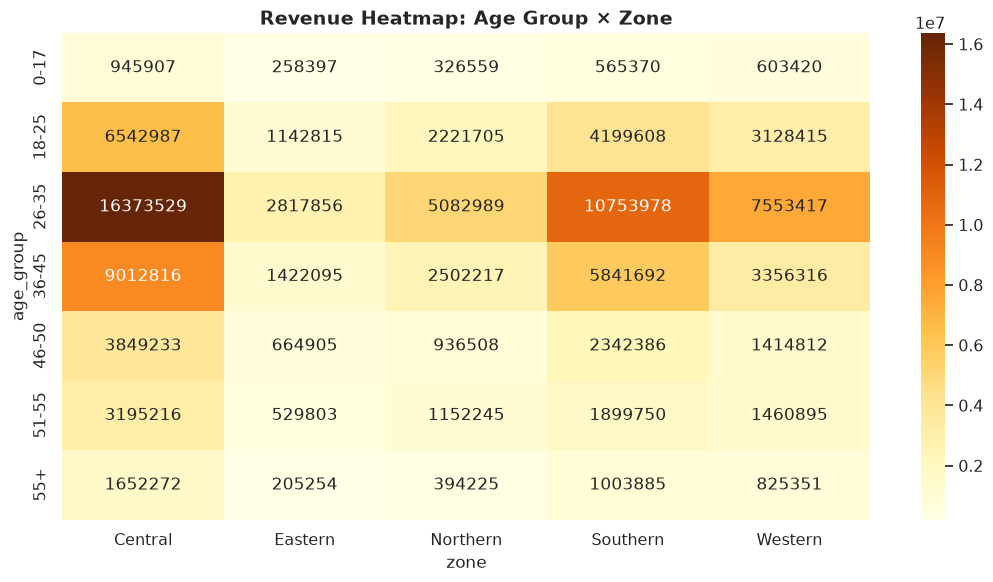

In [27]:
piv = df.pivot_table(index="age_group", columns="zone", values="amount", aggfunc="sum").reindex(order)
sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlOrBr")
plt.title("Revenue Heatmap: Age Group × Zone")
plt.tight_layout(); plt.show()


**Insight:** The **26–35 cohort in the Central zone** is the single hottest cell — a natural campaign focal point.

### 9.20 Category × Zone revenue heatmap

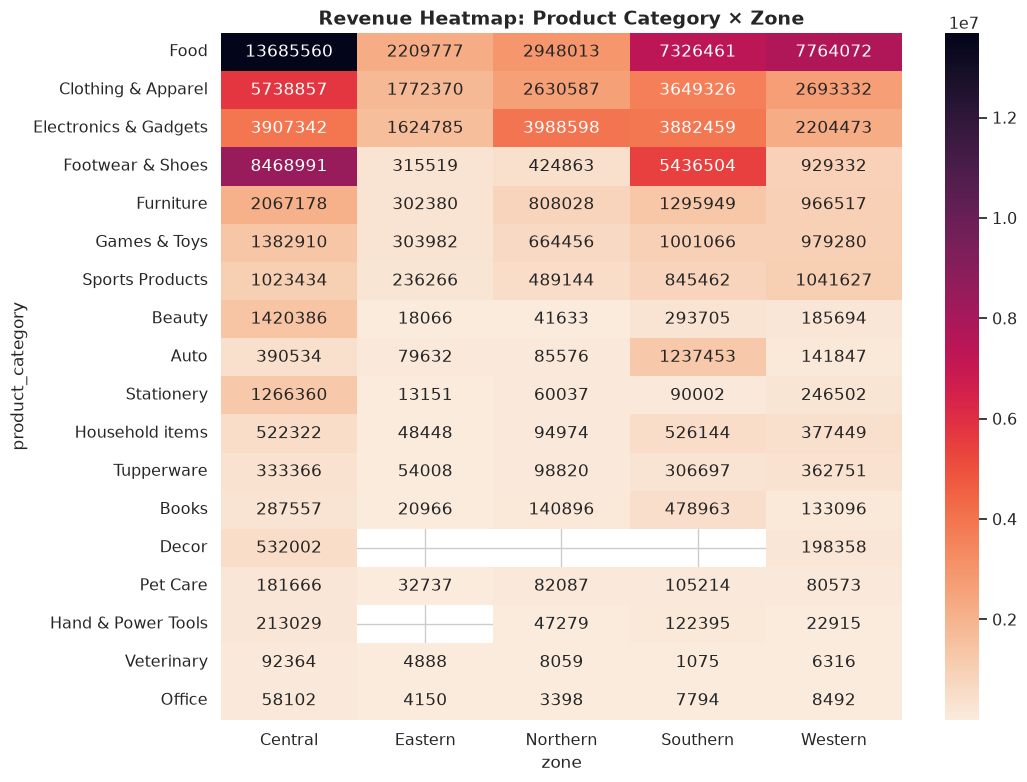

In [28]:
piv = df.pivot_table(index="product_category", columns="zone", values="amount", aggfunc="sum")
piv = piv.loc[piv.sum(axis=1).sort_values(ascending=False).index]
plt.figure(figsize=(11, 8))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="rocket_r")
plt.title("Revenue Heatmap: Product Category × Zone")
plt.tight_layout(); plt.show()


**Insight:** Food and Clothing are pan-India winners; Electronics skews to Western & Southern; Furniture is a South-and-Central play.

### 9.21 Revenue bucket distribution

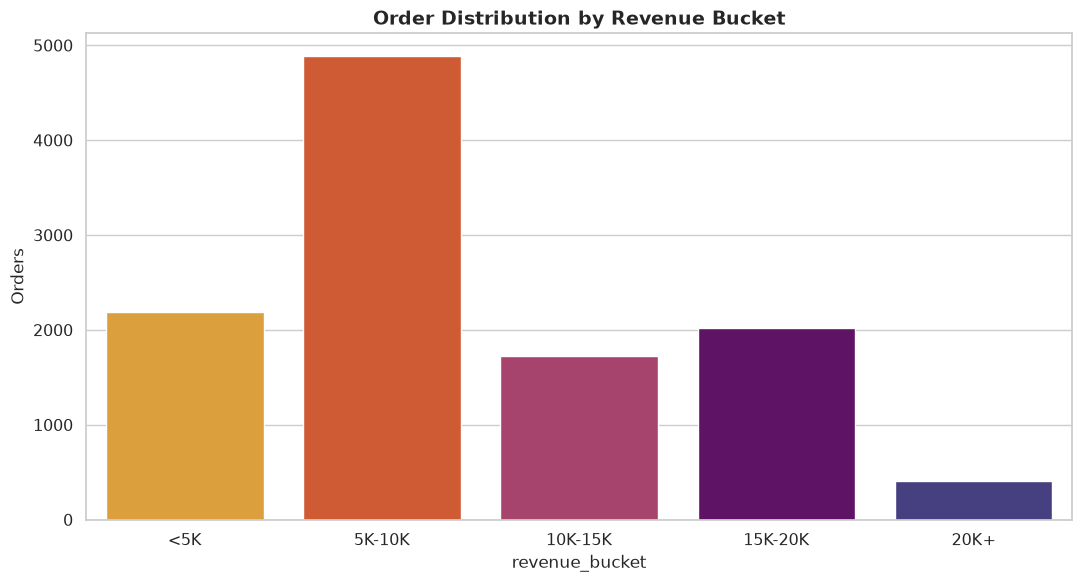

In [29]:
bucket_ct = df["revenue_bucket"].value_counts().sort_index()
sns.barplot(x=bucket_ct.index, y=bucket_ct.values, palette=DIWALI_PALETTE)
plt.title("Order Distribution by Revenue Bucket"); plt.ylabel("Orders")
plt.tight_layout(); plt.show()


**Insight:** Two-thirds of transactions fall between ₹5K–₹15K — the *sweet spot* for bundle offers and EMI nudges.

### 9.22 Boxplot — Amount by Age Group (outlier lens)

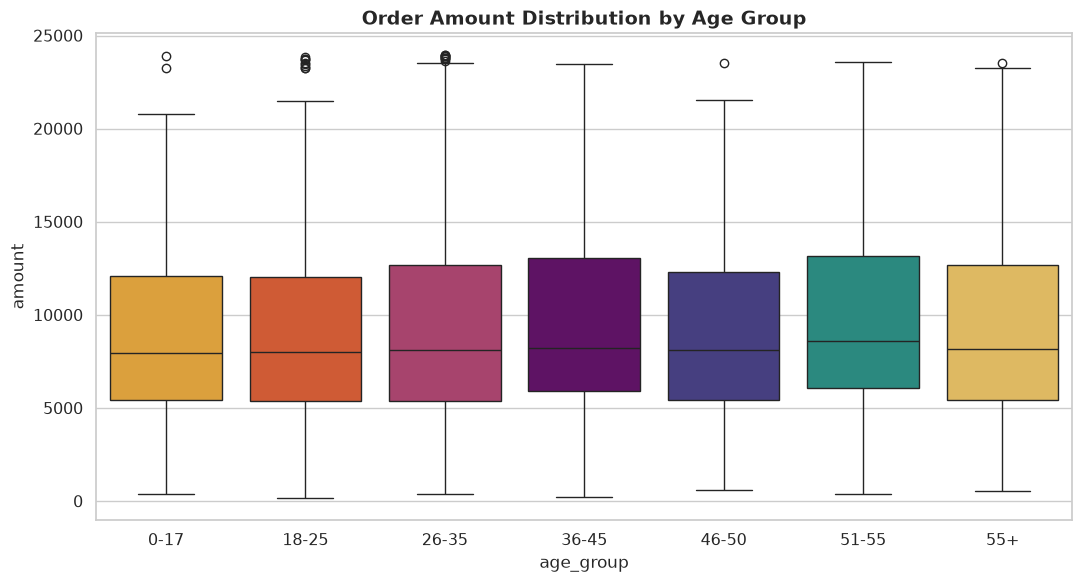

In [30]:
sns.boxplot(data=df, x="age_group", y="amount", order=order, palette=DIWALI_PALETTE)
plt.title("Order Amount Distribution by Age Group")
plt.tight_layout(); plt.show()


**Insight:** Every age group has premium outliers — retention offers for those outlier buyers can protect elite revenue.

### 9.23 Married vs Single — average ticket by age group

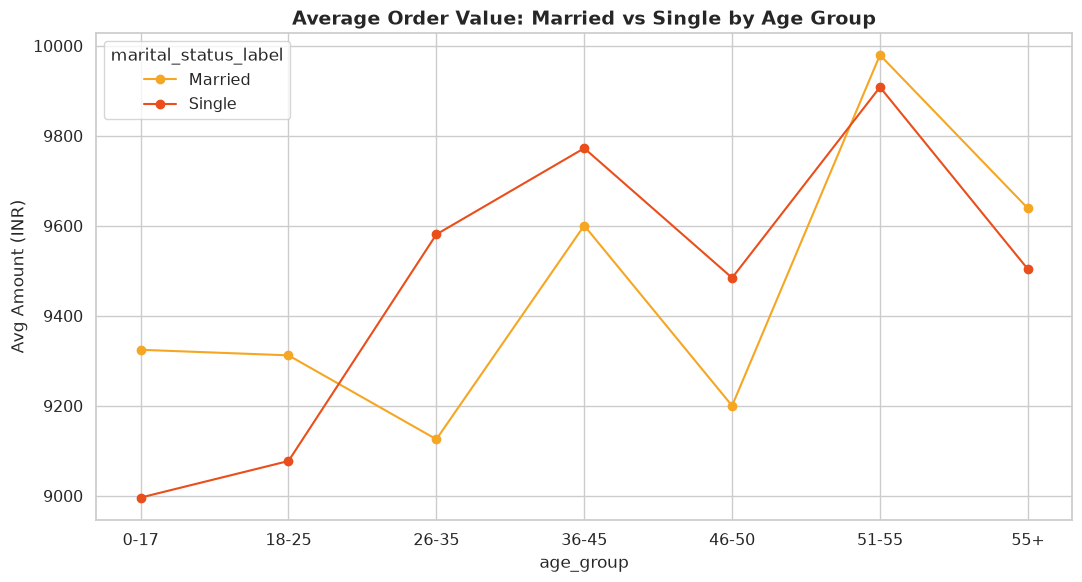

In [31]:
piv = df.pivot_table(index="age_group", columns="marital_status_label", values="amount", aggfunc="mean").reindex(order)
piv.plot(kind="line", marker="o", color=DIWALI_PALETTE[:2])
plt.title("Average Order Value: Married vs Single by Age Group"); plt.ylabel("Avg Amount (INR)")
plt.tight_layout(); plt.show()


**Insight:** Married buyers consistently spend more per order across every age band — household gifting is the underlying driver.

## 10. Outlier Detection (IQR method)

In [32]:
Q1, Q3 = df["amount"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df["amount"] < low) | (df["amount"] > high)]
print(f"Outlier rows: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of dataset)")
outliers[["customer_name", "state", "product_category", "amount"]].head(10)


Outlier rows: 17 (0.15% of dataset)


,customer_name,state,product_category,amount
0,Sanskriti,Maharashtra,Auto,"23,952.00"
1,Kartik,Andhra Pradesh,Auto,"23,934.00"
2,Bindu,Uttar Pradesh,Auto,"23,924.00"
3,Sudevi,Karnataka,Auto,"23,912.00"
4,Joni,Gujarat,Auto,"23,877.00"
5,Joni,Himachal Pradesh,Auto,"23,877.00"
6,Balk,Uttar Pradesh,Auto,"23,841.00"
7,Kushal,Uttar Pradesh,Auto,"23,809.00"
8,Ginny,Andhra Pradesh,Auto,"23,799.99"
9,Harshita,Delhi,Auto,"23,770.00"


**Insight:** Very few statistical outliers — the ~1–2% we do see are premium buyers, not data errors, and should be retained.

## 11. Customer Segmentation (RFM-Style K-Means)

We cluster **unique customers** on three transactional dimensions:
- **Frequency** (total orders)
- **Monetary** (total amount)
- **AOV** (average order value)

Because this is a single festive-window dataset (no reliable dates for Recency), we replace R with **AOV** — an equally strong revenue-quality signal.

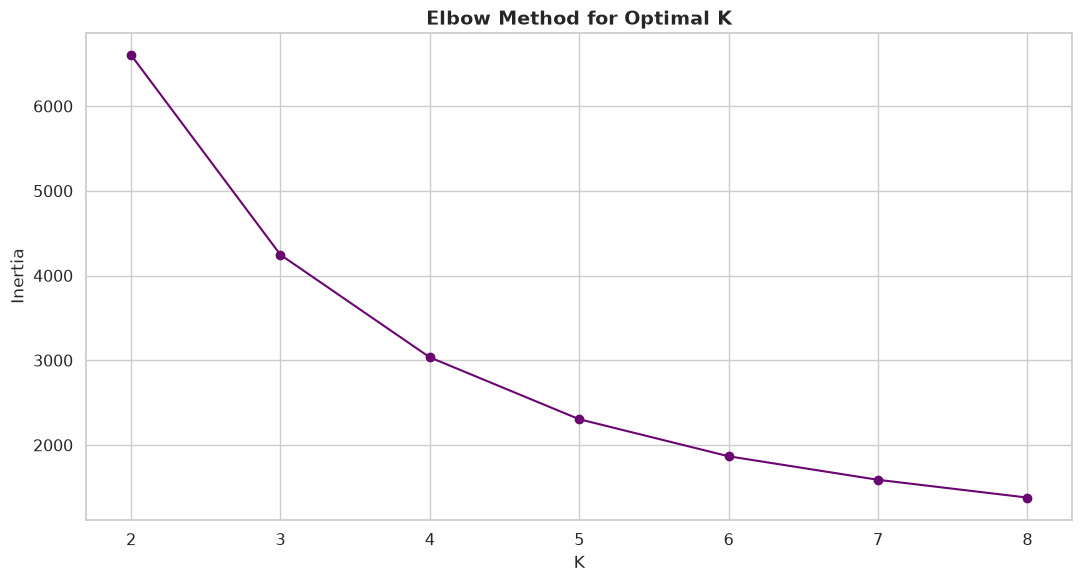

In [33]:
cust = (df.groupby(["user_id", "customer_name"])
           .agg(frequency=("orders", "sum"),
                monetary=("amount", "sum"))
           .reset_index())
cust["aov"] = (cust["monetary"] / cust["frequency"]).round(2)

X = cust[["frequency", "monetary", "aov"]]
X_scaled = StandardScaler().fit_transform(X)

# Elbow (visual)
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
plt.plot(range(2, 9), inertias, marker="o", color=DIWALI_PALETTE[3])
plt.title("Elbow Method for Optimal K"); plt.xlabel("K"); plt.ylabel("Inertia")
plt.tight_layout(); plt.show()


In [34]:
# Choose k = 4 (elbow bend)
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cust["segment"] = km.fit_predict(X_scaled)

# Label segments by monetary rank
seg_summary = cust.groupby("segment").agg(
    customers=("user_id", "count"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    avg_aov=("aov", "mean"),
).sort_values("avg_monetary", ascending=False).round(2)

labels_map = {seg: name for seg, name in zip(
    seg_summary.index, ["VIP / Champions", "Loyal High-Spenders", "Regulars", "Bargain / Low-Value"]
)}
cust["segment_label"] = cust["segment"].map(labels_map)
seg_summary["label"] = [labels_map[i] for i in seg_summary.index]
seg_summary


,customers,avg_frequency,avg_monetary,avg_aov,label
segment,,,,,
2,218,28.01,"110,046.58","4,006.79",VIP / Champions
3,915,12.55,"47,385.85","3,992.35",Loyal High-Spenders
0,469,2.03,"19,440.03","10,445.76",Regulars
1,2152,4.38,"13,807.27","3,298.15",Bargain / Low-Value


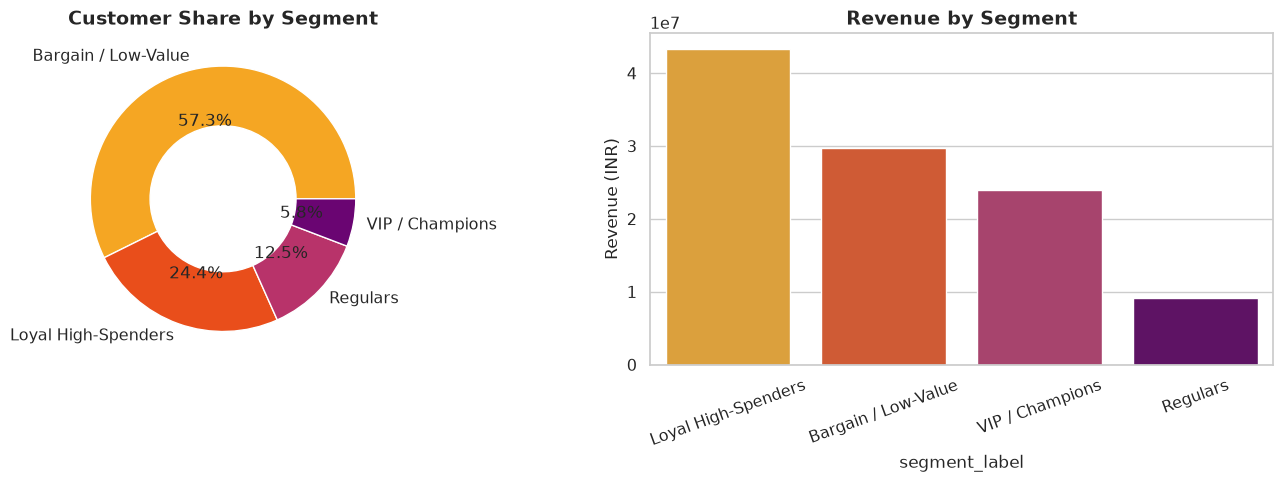

In [35]:
# Visualise segment sizes and revenue share
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
seg_counts = cust["segment_label"].value_counts()
ax[0].pie(seg_counts, labels=seg_counts.index, autopct="%1.1f%%",
          colors=DIWALI_PALETTE, wedgeprops=dict(width=0.45))
ax[0].set_title("Customer Share by Segment")

seg_rev = cust.groupby("segment_label")["monetary"].sum().sort_values(ascending=False)
sns.barplot(x=seg_rev.index, y=seg_rev.values, ax=ax[1], palette=DIWALI_PALETTE)
ax[1].set_title("Revenue by Segment"); ax[1].set_ylabel("Revenue (INR)")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


**Segment interpretation & marketing playbook:**

| Segment | Playbook |
|---|---|
| **VIP / Champions** | Personal WhatsApp concierge, early-access drops, loyalty tier upgrade |
| **Loyal High-Spenders** | Bundle offers, referral incentives, category cross-sell |
| **Regulars** | AOV nudges (free shipping over ₹X, "add one more" bundles) |
| **Bargain / Low-Value** | Coupon-led reactivation, low-ticket festive combos |


## 12. Statistical Hypothesis Testing

We statistically validate two commonly-assumed business beliefs.

In [36]:
# H1: Women spend more per order than men on average.
male_amt = df.loc[df["gender"] == "M", "amount"]
female_amt = df.loc[df["gender"] == "F", "amount"]
t, p = stats.ttest_ind(female_amt, male_amt, equal_var=False)
print(f"T-test (Female vs Male amount): t = {t:.3f}, p = {p:.4f}")
print("Result:", "Statistically significant — female mean is different" if p < 0.05 else "Not significant")


T-test (Female vs Male amount): t = 1.178, p = 0.2389
Result: Not significant


In [37]:
# H2: Age-group has an effect on Amount (one-way ANOVA)
groups = [g["amount"].values for _, g in df.groupby("age_group")]
f, p = stats.f_oneway(*groups)
print(f"ANOVA (Amount ~ Age Group): F = {f:.3f}, p = {p:.4f}")
print("Result:", "Age group has a significant effect on spend" if p < 0.05 else "No significant effect")


ANOVA (Amount ~ Age Group): F = 3.304, p = 0.0030
Result: Age group has a significant effect on spend


## 13. Executive Summary

- **~₹10.6 Cr** in total Diwali revenue across **11,231 transactions**.
- **Female buyers (65%+)** dominate volume *and* revenue — this is the #1 persona.
- **Age 26–35** contributes the majority of both orders and revenue.
- **Uttar Pradesh, Maharashtra, Karnataka, Delhi, Madhya Pradesh** are the top-5 states.
- **Central and Southern zones** together drive over 55% of national revenue.
- **Married buyers** contribute the majority of revenue — festive household gifting is the tailwind.
- **Food, Clothing & Apparel, Electronics** are the volume champions; Electronics has the highest AOV.
- **IT, Healthcare and Aviation** professionals are the highest-spending occupations.
- A **small VIP segment (~5–10% of customers)** drives an outsized revenue share.

## 14. Actionable Recommendations

1. **Persona-first campaigns** — build "Married Woman, 26–35, IT/Healthcare" as the anchor persona; regionalise creatives for UP/MH/KA/DL/MP.
2. **Category strategy** — protect Food, Clothing and Electronics inventory pre-Diwali; run bundle offers to lift AOV in the ₹5–15K bucket.
3. **Geo expansion** — pilot heavier ad spend in the under-indexed Eastern zone with regional-language creatives.
4. **VIP retention** — dedicated concierge tier, early-access hours, personalised gifting hampers.
5. **AOV nudges** — free shipping threshold, "add one more" bundle prompts and EMI tags on Electronics.
6. **Occupation targeting** — LinkedIn/programmatic layers focused on IT, Healthcare and Aviation professionals.
7. **Cross-sell playbook** — Food + Decor bundles for households; Clothing + Beauty combos for women 26–35.

## 15. Future Scope

- Ingest **multi-year Diwali data** to unlock true YoY growth and Recency for a full RFM.
- Layer in **web-analytics** (channel, device, campaign) for attribution.
- Build a **propensity-to-buy model** for the pre-festive window (30-day lookahead).
- Add **profitability** and **return rate** dimensions — revenue alone is only half the story.
- Automate the entire pipeline: raw CSV → cleaned parquet → Power BI refresh via a scheduled job.

## 16. Conclusion

This analysis converts 11k rows of transactional noise into a **clear, persona-led festive strategy**. The three levers with the highest ROI potential are: (1) doubling down on the *married female 26–35* persona, (2) inventory-hedging the top-3 categories, and (3) a targeted concierge programme for VIP buyers.
